In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as pe
import numpy as np

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


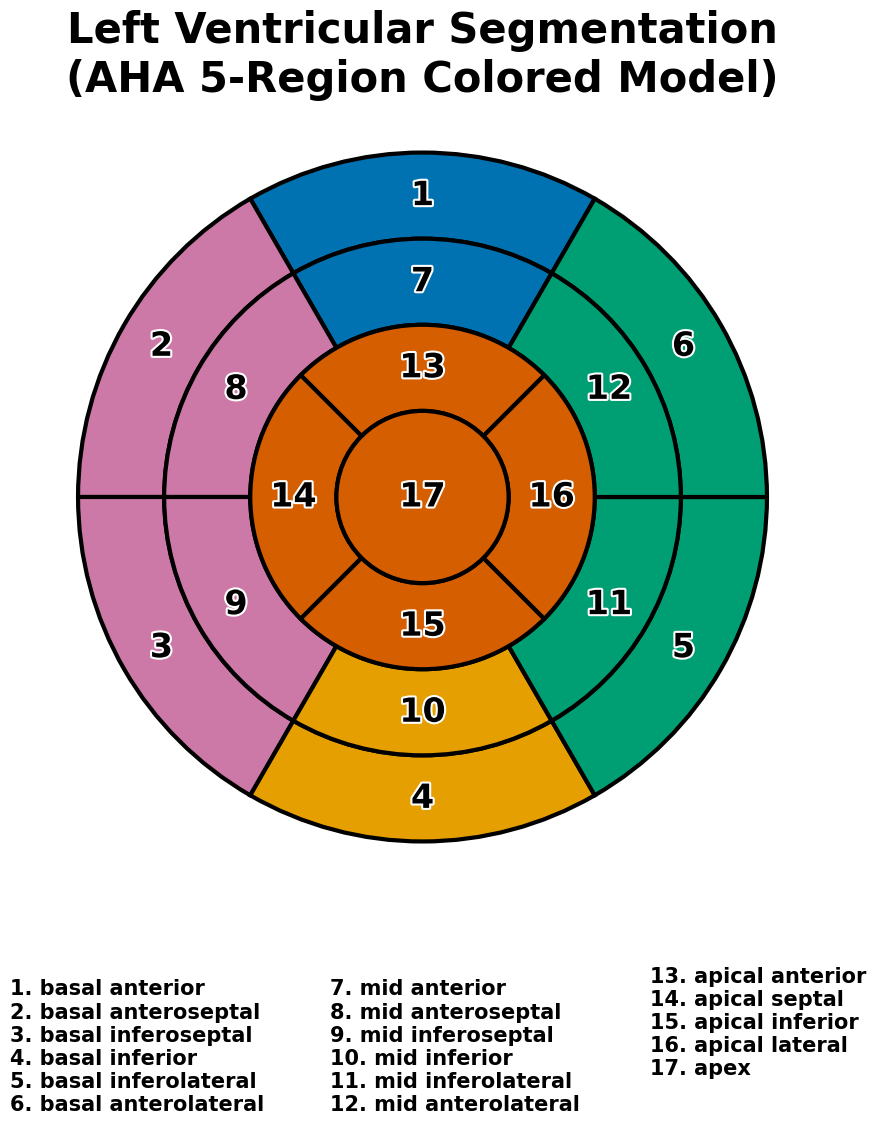

In [5]:


# 1. 定义节段到对应区域颜色的映射
color_map = {
    1: '#0072B2', 7: '#0072B2', # Anterior (前壁)
    5: '#009E73', 6: '#009E73', 11: '#009E73', 12: '#009E73', # Lateral (侧壁)
    4: '#E69F00', 10: '#E69F00', # Inferior (下壁)
    2: '#CC79A7', 3: '#CC79A7', 8: '#CC79A7', 9: '#CC79A7', # Septal (室间隔)
    13: '#D55E00', 14: '#D55E00', 15: '#D55E00', 16: '#D55E00', 17: '#D55E00' # Apical (心尖)
}

# 2. 初始化画布
fig, ax = plt.subplots(figsize=(10, 12))
plt.subplots_adjust(bottom=0.25)
ax.axis('equal')
ax.axis('off')

# 定义靶心图的四个半径层级
r_apex = 1
r_apical = 2
r_mid = 3
r_basal = 4

# 为文字添加白色描边效果，确保在各种底色上都清晰可见
text_effect = [pe.withStroke(linewidth=3, foreground='white')]

def draw_ring(r_inner, r_outer, num_segments, start_angle, labels):
    """
    绘制同心圆环中的独立扇形区域、填色并添加对应编号
    """
    angle_step = 360 / num_segments
    for i in range(num_segments):
        theta1 = start_angle + i * angle_step
        theta2 = start_angle + (i + 1) * angle_step
        
        label = labels[i]
        
        # 绘制扇形边界并根据映射表填充对应颜色
        wedge = patches.Wedge(
            center=(0,0), r=r_outer, theta1=theta1, theta2=theta2, 
            width=(r_outer - r_inner), 
            edgecolor='black', facecolor=color_map[label], linewidth=3
        )
        ax.add_patch(wedge)
        
        # 计算扇形中心坐标用于放置文本
        theta_mid = np.deg2rad((theta1 + theta2) / 2)
        r_text = (r_inner + r_outer) / 2
        x_text = r_text * np.cos(theta_mid)
        y_text = r_text * np.sin(theta_mid)
        
        # 插入区域编号（带描边）
        ax.text(x_text, y_text, str(label), ha='center', va='center', 
                fontsize=24, fontweight='bold', color='black', path_effects=text_effect)

# 3. 按层级绘制各个节段
# 底部环 (Basal, 1-6)
draw_ring(r_mid, r_basal, 6, 60, [1, 2, 3, 4, 5, 6])
# 中部环 (Mid, 7-12)
draw_ring(r_apical, r_mid, 6, 60, [7, 8, 9, 10, 11, 12])
# 心尖环 (Apical, 13-16)
draw_ring(r_apex, r_apical, 4, 45, [13, 14, 15, 16])

# 4. 绘制心尖中心 (Apex, 17)
circle = patches.Circle((0,0), r_apex, edgecolor='black', facecolor=color_map[17], linewidth=3)
ax.add_patch(circle)
ax.text(0, 0, '17', ha='center', va='center', fontsize=24, fontweight='bold', color='black', path_effects=text_effect)

# 添加标题
plt.title("Left Ventricular Segmentation\n(AHA 5-Region Colored Model)", fontsize=30, fontweight='bold', pad=20)

# 固定坐标轴范围以防图形拉伸
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-4.5, 4.5)

# 5. 构建底部图例文本结构
legend_col1 = (
    "1. basal anterior\n"
    "2. basal anteroseptal\n"
    "3. basal inferoseptal\n"
    "4. basal inferior\n"
    "5. basal inferolateral\n"
    "6. basal anterolateral"
)
legend_col2 = (
    "7. mid anterior\n"
    "8. mid anteroseptal\n"
    "9. mid inferoseptal\n"
    "10. mid inferior\n"
    "11. mid inferolateral\n"
    "12. mid anterolateral"
)
legend_col3 = (
    "13. apical anterior\n"
    "14. apical septal\n"
    "15. apical inferior\n"
    "16. apical lateral\n"
    "17. apex"
)

# 在画布底层精确放置三列图例
fig.text(0.10, 0.05, legend_col1, fontsize=15, va='bottom', ha='left', fontweight='bold')
fig.text(0.42, 0.05, legend_col2, fontsize=15, va='bottom', ha='left', fontweight='bold')
fig.text(0.74, 0.08, legend_col3, fontsize=15, va='bottom', ha='left', fontweight='bold')

plt.savefig("aha_17_colored.png", dpi=600)
plt.show()